In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline


In [2]:
df = pd.read_csv("/Users/ameer/Task4/PJM(AEP)_energy_dataset.csv")

In [4]:
df.isnull().sum()

Datetime    0
PJME_MW     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [7]:
df.set_index("Datetime", inplace=True)

In [9]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

In [10]:
missing = full_range.difference(df.index)

print("Missing timestamps:", len(missing))

Missing timestamps: 30


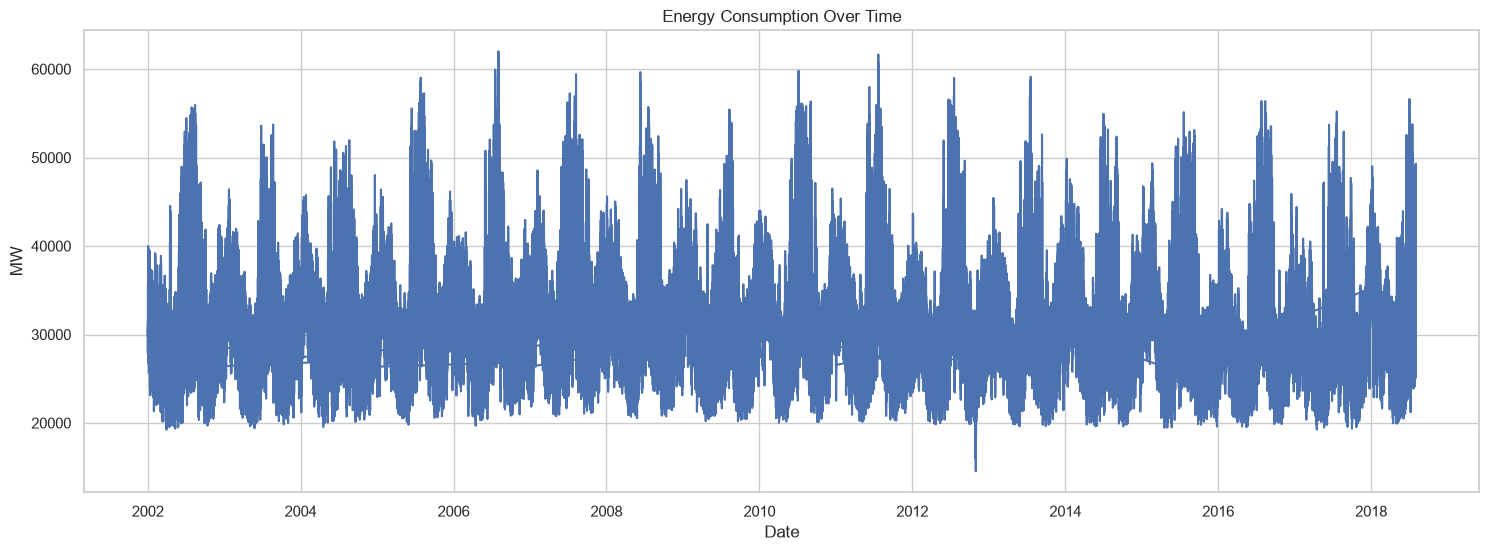

In [11]:
plt.figure(figsize=(18,6))

plt.plot(df.index, df["PJME_MW"])

plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("MW")

plt.show()

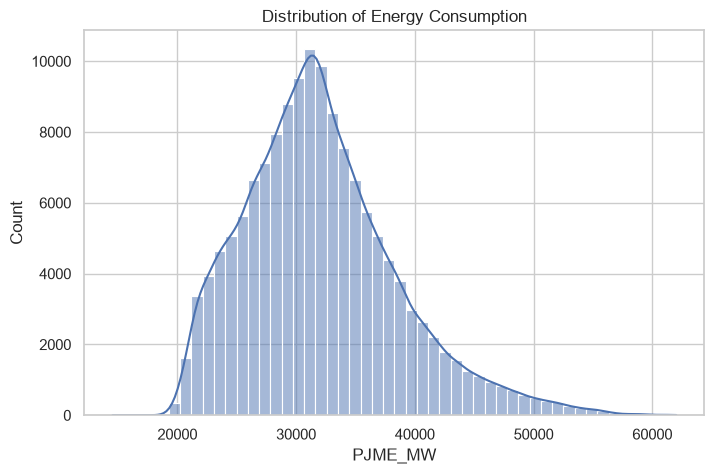

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["PJME_MW"], bins=50, kde=True)

plt.title("Distribution of Energy Consumption")

plt.show()

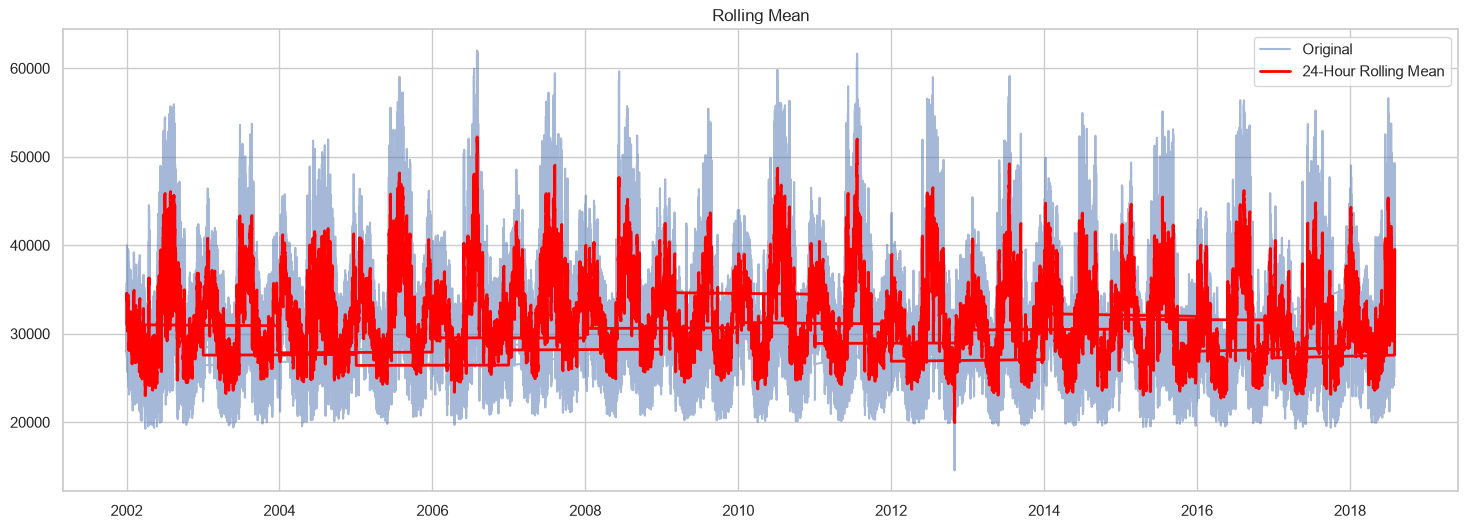

In [14]:
df["Rolling_Mean_24"] = df["PJME_MW"].rolling(window=24).mean()

plt.figure(figsize=(18,6))

plt.plot(df["PJME_MW"], alpha=0.5, label="Original")
plt.plot(df["Rolling_Mean_24"], color="red", linewidth=2, label="24-Hour Rolling Mean")

plt.legend()

plt.title("Rolling Mean")

plt.show()

Time Features

In [15]:
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Day"] = df.index.day
df["Hour"] = df.index.hour
df["Weekday"] = df.index.day_name()

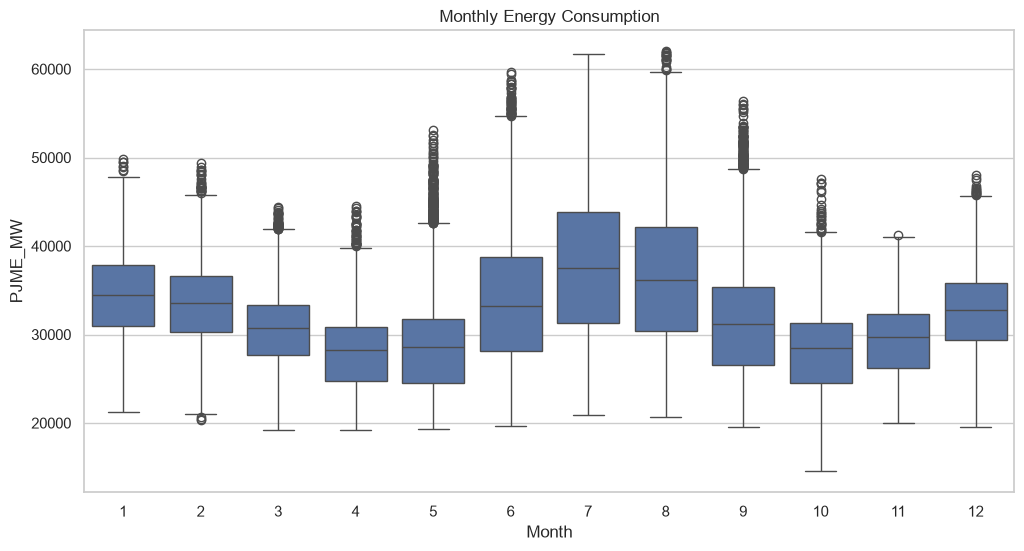

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Month",
    y="PJME_MW"
)

plt.title("Monthly Energy Consumption")

plt.show()

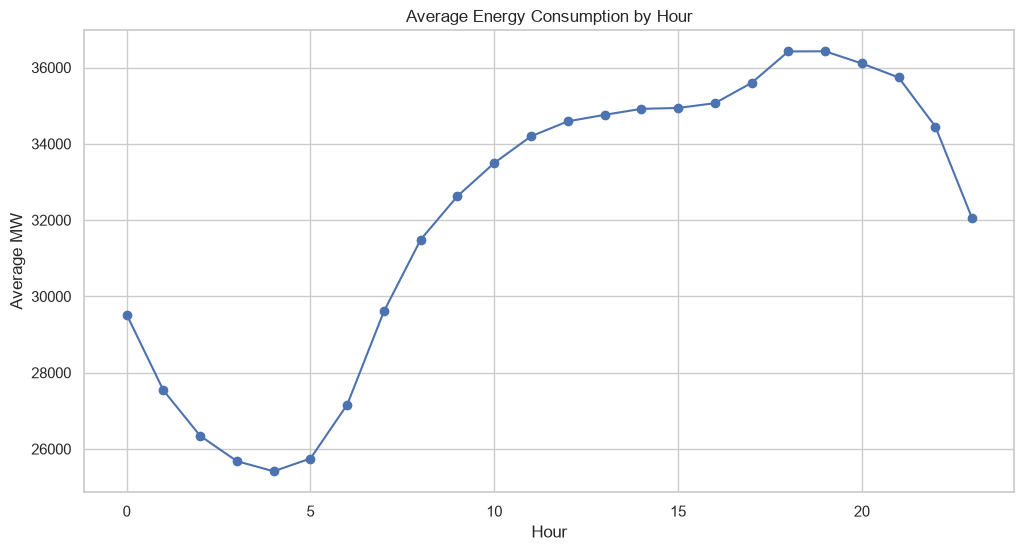

In [17]:
hourly = df.groupby("Hour")["PJME_MW"].mean()

plt.figure(figsize=(12,6))

plt.plot(hourly, marker="o")

plt.title("Average Energy Consumption by Hour")

plt.xlabel("Hour")
plt.ylabel("Average MW")

plt.grid(True)

plt.show()

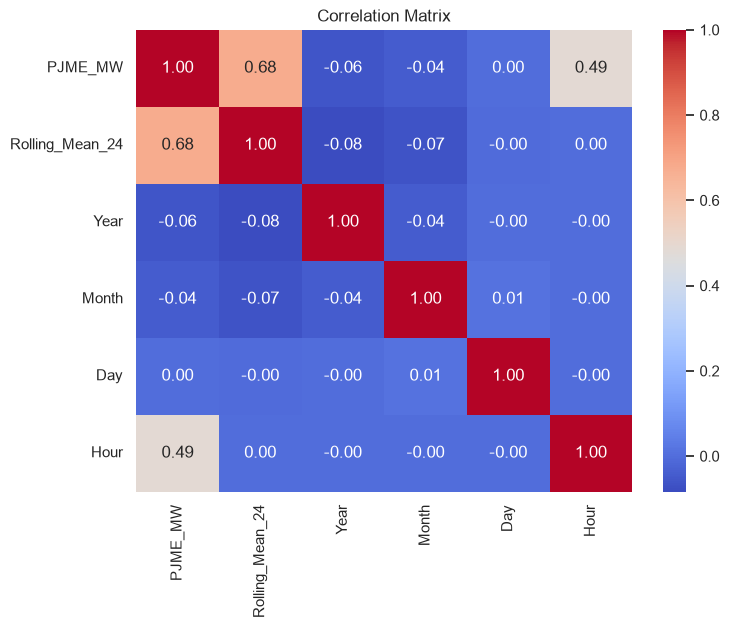

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

<Figure size 1200x500 with 0 Axes>

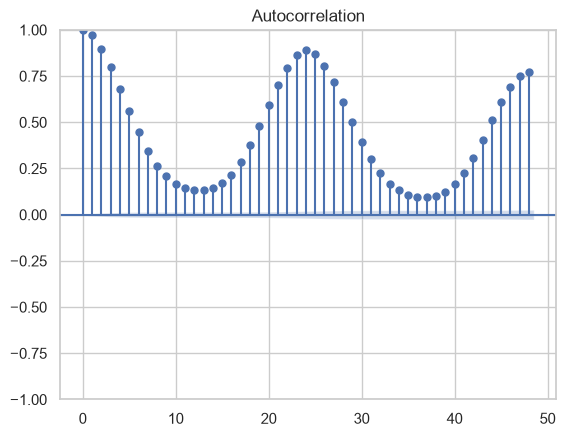

In [19]:
plt.figure(figsize=(12,5))

plot_acf(
    df["PJME_MW"],
    lags=48
)

plt.show()

<Figure size 1200x500 with 0 Axes>

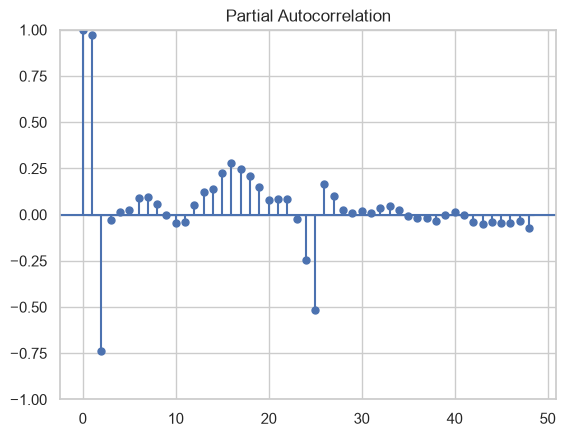

In [20]:
plt.figure(figsize=(12,5))

plot_pacf(
    df["PJME_MW"],
    lags=48
)

plt.show()

In [21]:
result = adfuller(df["PJME_MW"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -18.82891272908423
p-value : 2.022124508152674e-30

Critical Values:
1% : -3.430395009088914
5% : -2.861559893380481
10% : -2.5667805885384065


In [22]:
if result[1] < 0.05:
    print("The series is Stationary.")
else:
    print("The series is NOT Stationary.")

The series is Stationary.


In [23]:
df["Z_score"] = zscore(df["PJME_MW"])

outliers = df[np.abs(df["Z_score"]) > 3]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 1318


,PJME_MW,Rolling_Mean_24,Year,Month,Day,Hour,Weekday,Z_score
Datetime,,,,,,,,
2002-08-19 14:00:00,52145.0,42403.333333,2002,8,19,14,Monday,3.104085
2002-08-19 15:00:00,53094.0,42588.250000,2002,8,19,15,Monday,3.250899
2002-08-19 16:00:00,53575.0,42780.916667,2002,8,19,16,Monday,3.325311
2002-08-19 17:00:00,53739.0,42972.958333,2002,8,19,17,Monday,3.350682
2002-08-19 18:00:00,53202.0,43163.083333,2002,8,19,18,Monday,3.267607


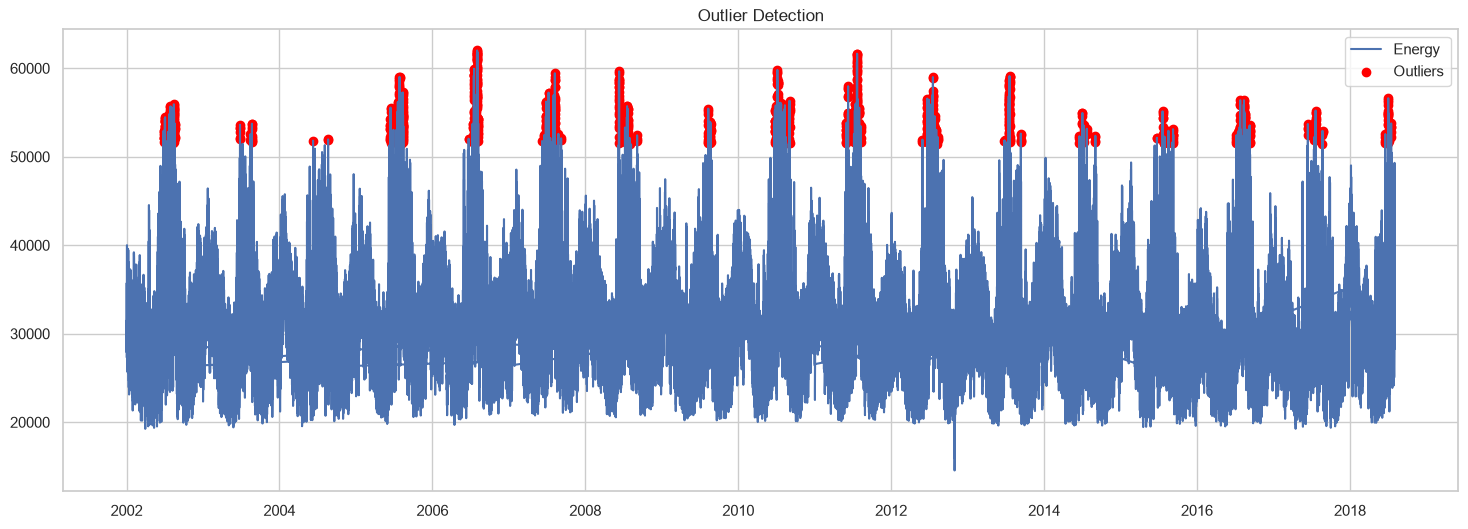

In [24]:
plt.figure(figsize=(18,6))

plt.plot(df.index, df["PJME_MW"], label="Energy")

plt.scatter(
    outliers.index,
    outliers["PJME_MW"],
    color="red",
    label="Outliers"
)

plt.legend()

plt.title("Outlier Detection")

plt.show()